In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans

In [2]:
# Dataset
X, y_true = make_blobs(
    n_samples=600,
    centers=4,
    cluster_std=[1.0, 1.2, 0.8, 1.4],
    random_state=42
)

X = StandardScaler().fit_transform(X)

print("Shape:", X.shape)

Shape: (600, 2)


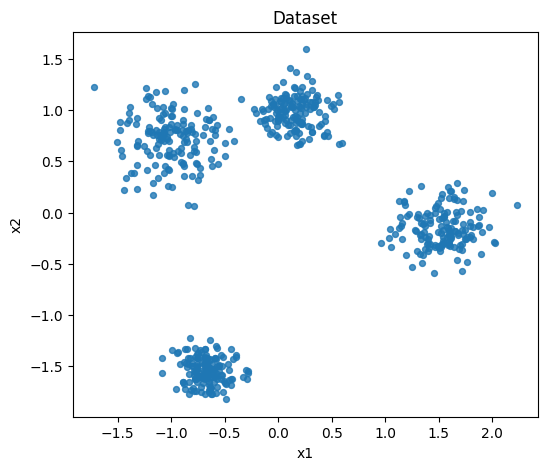

In [3]:
def plot_points(X, title="Data", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    return ax


def plot_clusters(X, labels, centers=None, title="Clusters", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, s=18, alpha=0.85)
    if centers is not None:
        ax.scatter(centers[:, 0], centers[:, 1], s=220, marker="X", edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    return ax


plot_points(X, "Dataset")
plt.show()

## From scratch

In [4]:
def squared_euclidean_distances(X, centers):
    """
    D[i, k] = ||X[i] - centers[k]||^2
    """
    diff = X[:, None, :] - centers[None, :, :]    # (n,1,d) - (1,K,d) -> (n,K,d)
    D = np.sum(diff * diff, axis=2)
    return D


def assign_clusters(X, centers):
    D = squared_euclidean_distances(X, centers)
    labels = np.argmin(D, axis=1)
    return labels, D


def compute_inertia(X, centers, labels=None):
    if labels is None:
        labels, _ = assign_clusters(X, centers)
    inertia = 0.0
    for k in range(centers.shape[0]):
        Xk = X[labels == k]
        if len(Xk) > 0:
            inertia += np.sum((Xk - centers[k]) ** 2)
    return float(inertia)

In [5]:
def init_random_centers(X, k, rng):
    idx = rng.choice(X.shape[0], size=k, replace=False)
    return X[idx].copy()


def init_kmeans_plus_plus(X, k, rng):
    """
    Inicialización K-means++
    """
    n = X.shape[0]
    centers = []

    # Primer centro
    first_idx = rng.integers(0, n)
    centers.append(X[first_idx].copy())

    # Distancia cuadrada al centro más cercano actual
    closest_dist_sq = np.sum((X - centers[0]) ** 2, axis=1)

    for _ in range(1, k):
        probs = closest_dist_sq / np.sum(closest_dist_sq)
        next_idx = rng.choice(n, p=probs)
        centers.append(X[next_idx].copy())

        new_dist_sq = np.sum((X - centers[-1]) ** 2, axis=1)
        closest_dist_sq = np.minimum(closest_dist_sq, new_dist_sq)

    return np.array(centers)

In [6]:
def kmeans_from_scratch(
    X,
    k,
    init="random",      # "random", "kmeans++"
    max_iter=100,
    tol=1e-4,
    random_state=42,
    return_history=True
):
    rng = np.random.default_rng(random_state)

    if init == "random":
        centers = init_random_centers(X, k, rng)
    elif init == "kmeans++":
        centers = init_kmeans_plus_plus(X, k, rng)

    history = {
        "inertia": [],
        "centers": []
    }

    for _ in range(max_iter):
        labels, _ = assign_clusters(X, centers)

        new_centers = centers.copy()
        for j in range(k):
            Xj = X[labels == j]
            if len(Xj) > 0:
                new_centers[j] = Xj.mean(axis=0)

        inertia = compute_inertia(X, new_centers, labels)
        if return_history:
            history["inertia"].append(inertia)
            history["centers"].append(new_centers.copy())

        shift = np.linalg.norm(new_centers - centers)
        centers = new_centers

        if shift < tol:
            break

    labels, _ = assign_clusters(X, centers)
    inertia = compute_inertia(X, centers, labels)

    result = {
        "centers": centers,
        "labels": labels,
        "inertia": inertia,
        "n_iter": len(history["inertia"]) if return_history else None,
        "history": history if return_history else None
    }
    return result

In [7]:
k = 4

res_random = kmeans_from_scratch(X, k=k, init="random", random_state=7)
res_kpp    = kmeans_from_scratch(X, k=k, init="kmeans++", random_state=7)

print("K-means (random init)")
print("  Iteraciones:", res_random["n_iter"])
print("  Inercia final:", round(res_random["inertia"], 4))

print("\nK-means (k-means++)")
print("  Iteraciones:", res_kpp["n_iter"])
print("  Inercia final:", round(res_kpp["inertia"], 4))

K-means (random init)
  Iteraciones: 6
  Inercia final: 45.0208

K-means (k-means++)
  Iteraciones: 3
  Inercia final: 45.0208


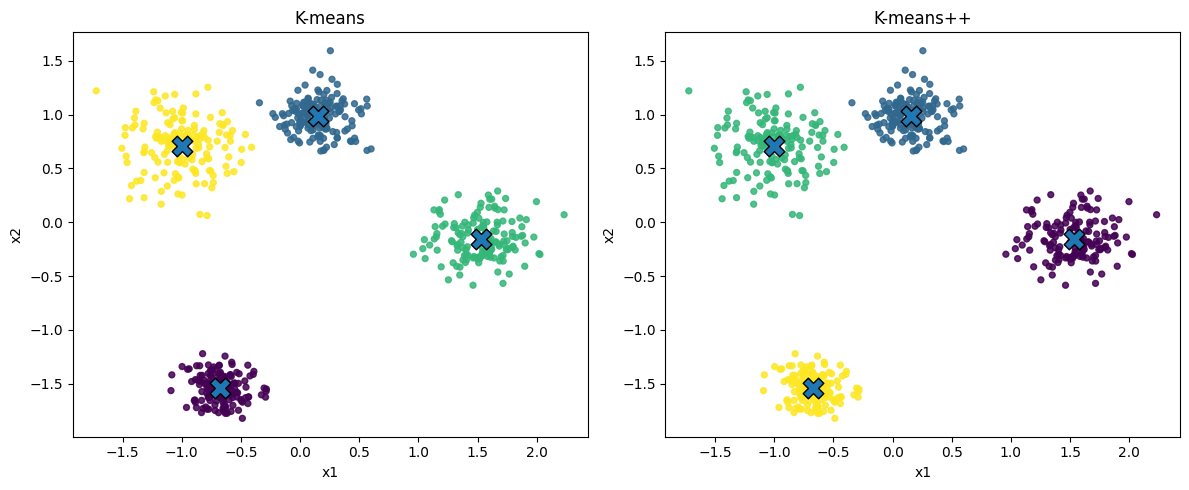

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_clusters(
    X, res_random["labels"], res_random["centers"],
    title="K-means",
    ax=axes[0]
)

plot_clusters(
    X, res_kpp["labels"], res_kpp["centers"],
    title="K-means++",
    ax=axes[1]
)

plt.tight_layout()
plt.show()

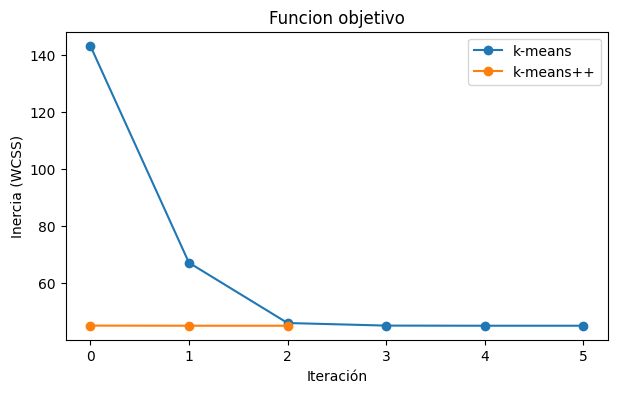

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(res_random["history"]["inertia"], marker="o", label="k-means")
ax.plot(res_kpp["history"]["inertia"], marker="o", label="k-means++")
ax.set_title("Funcion objetivo")
ax.set_xlabel("Iteración")
ax.set_ylabel("Inercia (WCSS)")
ax.legend()
plt.show()

In [10]:
def minibatch_kmeans_from_scratch(
    X,
    k,
    batch_size=64,
    init="kmeans++",    # "random" o "kmeans++"
    max_steps=300,
    random_state=42,
    return_history=True
):
    rng = np.random.default_rng(random_state)
    n, d = X.shape

    if init == "random":
        centers = init_random_centers(X, k, rng)
    elif init == "kmeans++":
        centers = init_kmeans_plus_plus(X, k, rng)

    counts = np.zeros(k, dtype=np.int64)

    history = {
        "inertia": [],
        "centers": []
    }

    for step in range(max_steps):
        batch_idx = rng.choice(n, size=batch_size, replace=False)
        Xb = X[batch_idx]

        labels_b, _ = assign_clusters(Xb, centers)

        # Actualización incremental por punto
        for x, j in zip(Xb, labels_b):
            counts[j] += 1
            eta = 1.0 / counts[j]
            centers[j] = centers[j] + eta * (x - centers[j])

        if return_history and (step % 10 == 0 or step == max_steps - 1):
            labels_full, _ = assign_clusters(X, centers)
            inertia_full = compute_inertia(X, centers, labels_full)
            history["inertia"].append(inertia_full)
            history["centers"].append(centers.copy())

    labels, _ = assign_clusters(X, centers)
    inertia = compute_inertia(X, centers, labels)

    result = {
        "centers": centers,
        "labels": labels,
        "inertia": inertia,
        "n_steps": max_steps,
        "history": history if return_history else None
    }
    return result

In [11]:
res_mbk = minibatch_kmeans_from_scratch(
    X, k=4, batch_size=64, init="kmeans++", max_steps=300, random_state=7
)

print("MiniBatch K-means")
print("  Steps:", res_mbk["n_steps"])
print("  Inercia final:", round(res_mbk["inertia"], 4))

MiniBatch K-means
  Steps: 300
  Inercia final: 45.0388


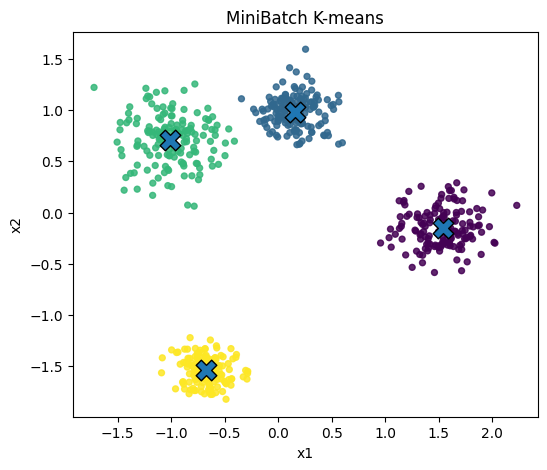

In [12]:
plot_clusters(
    X, res_mbk["labels"], res_mbk["centers"],
    title="MiniBatch K-means"
)
plt.show()

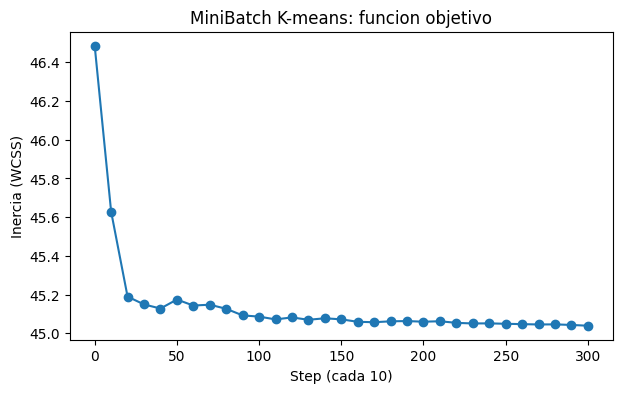

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(len(res_mbk["history"]["inertia"])) * 10,
        res_mbk["history"]["inertia"],
        marker="o")
ax.set_title("MiniBatch K-means: funcion objetivo")
ax.set_xlabel("Step (cada 10)")
ax.set_ylabel("Inercia (WCSS)")
plt.show()

## Sklearn

In [14]:
k = 4

km_sklearn = KMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=7
)
km_sklearn.fit(X)

mbk_sklearn = MiniBatchKMeans(
    n_clusters=k,
    init="k-means++",
    n_init=10,
    batch_size=64,
    max_iter=300,
    random_state=7
)
mbk_sklearn.fit(X)

print("scikit-learn KMeans")
print("  Iteraciones:", km_sklearn.n_iter_)
print("  Inercia final:", round(km_sklearn.inertia_, 4))

print("\nscikit-learn MiniBatchKMeans")
print("  Inercia final:", round(mbk_sklearn.inertia_, 4))

scikit-learn KMeans
  Iteraciones: 2
  Inercia final: 45.0208

scikit-learn MiniBatchKMeans
  Inercia final: 45.1511


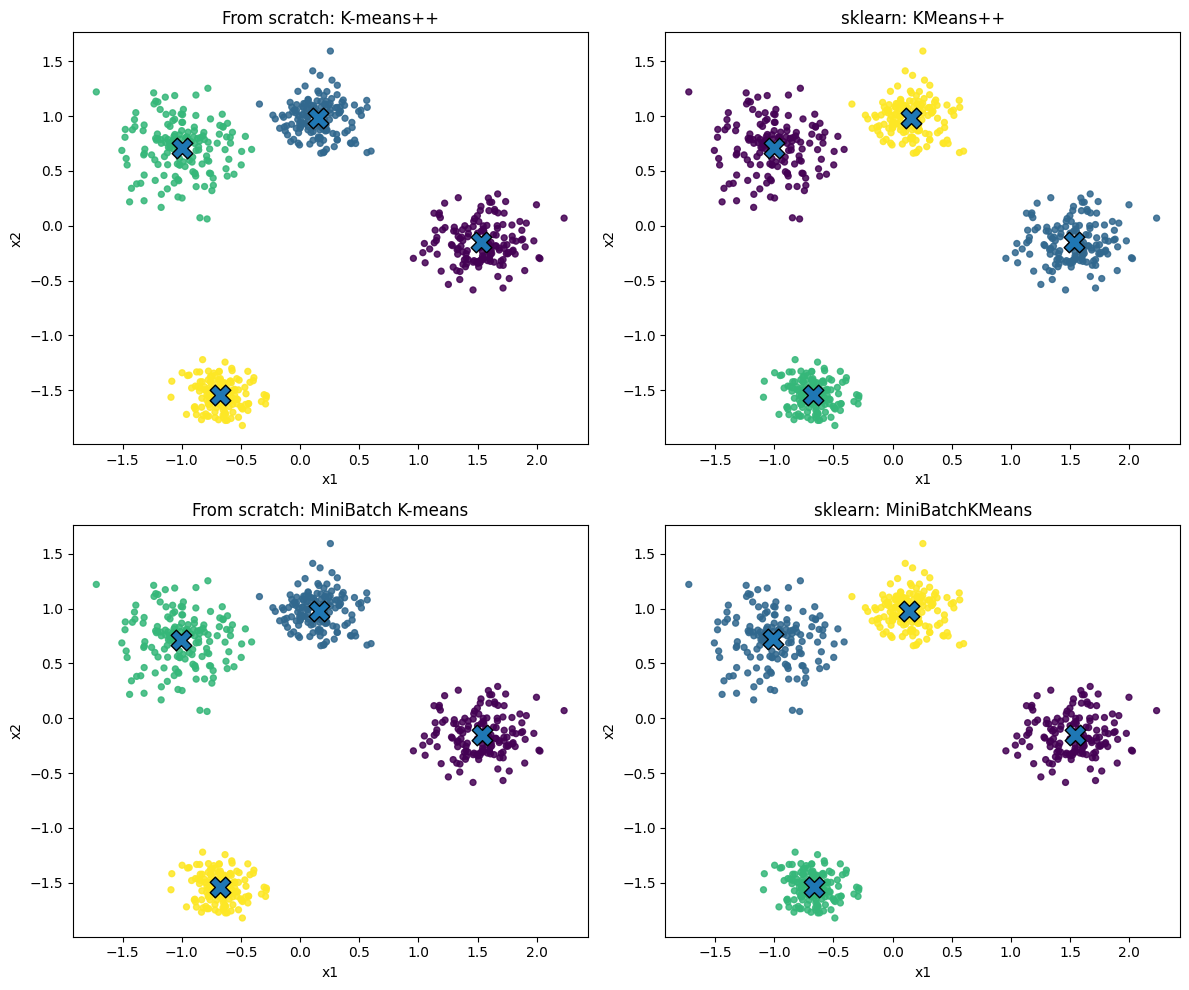

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_clusters(
    X, res_kpp["labels"], res_kpp["centers"],
    title="From scratch: K-means++",
    ax=axes[0, 0]
)

plot_clusters(
    X, km_sklearn.labels_, km_sklearn.cluster_centers_,
    title="sklearn: KMeans++",
    ax=axes[0, 1]
)

plot_clusters(
    X, res_mbk["labels"], res_mbk["centers"],
    title="From scratch: MiniBatch K-means",
    ax=axes[1, 0]
)

plot_clusters(
    X, mbk_sklearn.labels_, mbk_sklearn.cluster_centers_,
    title="sklearn: MiniBatchKMeans",
    ax=axes[1, 1]
)

plt.tight_layout()
plt.show()

## Caso no lineal

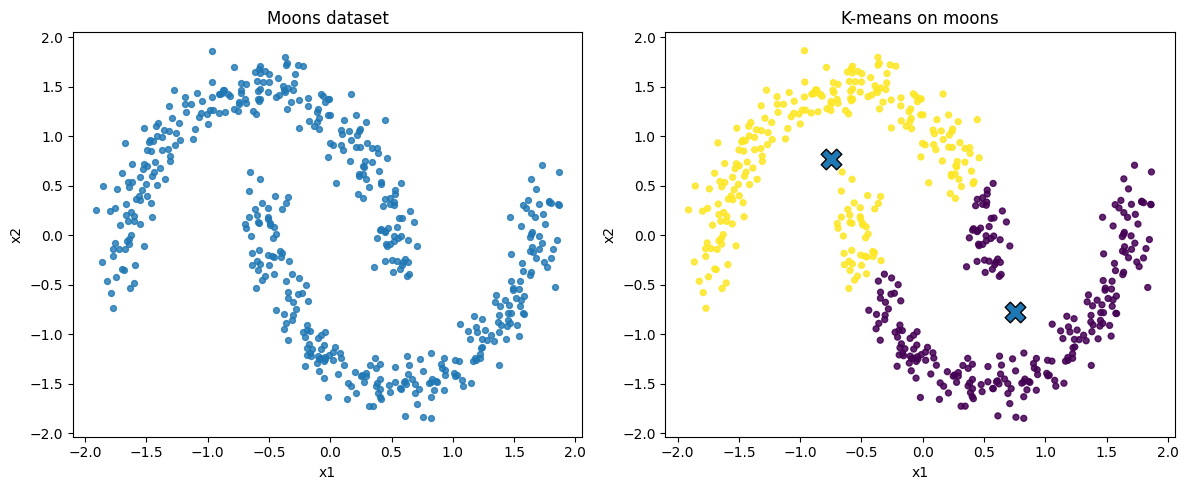

In [16]:
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=42)
X_moons = StandardScaler().fit_transform(X_moons)

res_moons = kmeans_from_scratch(X_moons, k=2, init="kmeans++", random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_points(X_moons, "Moons dataset", ax=axes[0])
plot_clusters(
    X_moons, res_moons["labels"], res_moons["centers"],
    title="K-means on moons",
    ax=axes[1]
)
plt.tight_layout()
plt.show()